# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [1]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [2]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [3]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [4]:
print("ДО виклику set_seed()")
numbers1 = list(range(10))
rand_val1 = random.randint(1, 100)
random.shuffle(numbers1)
print(f"Генерація 1 - Число: {rand_val1}, Список: {numbers1}")

numbers2 = list(range(10))
rand_val2 = random.randint(1, 100)
random.shuffle(numbers2)
print(f"Генерація 2 - Число: {rand_val2}, Список: {numbers2}")


print("\nПІСЛЯ з викликом set_seed() після кожної генерації")
set_seed()
print("SEED зафіксовано", SEED)
numbers3 = list(range(10))
rand_val3 = random.randint(1, 100)
random.shuffle(numbers3)
print(f"Генерація 1 - Число: {rand_val3}, Список: {numbers3}")

set_seed()
print("SEED зафіксовано", SEED)
numbers4 = list(range(10))
rand_val4 = random.randint(1, 100)
random.shuffle(numbers4)
print(f"Генерація 2 - Число: {rand_val4}, Список: {numbers4}")


print("\nПІСЛЯ з викликом set_seed() з одним викликом на початку")
set_seed()
print("SEED зафіксовано", SEED)

numbers5 = list(range(10))
rand_val5 = random.randint(1, 100)
random.shuffle(numbers5)
print(f"Генерація 1 - Число: {rand_val5}, Список: {numbers5}")

numbers6 = list(range(10))
rand_val6 = random.randint(1, 100)
random.shuffle(numbers6)
print(f"Генерація 2 - Число: {rand_val6}, Список: {numbers6}")

ДО виклику set_seed()
Генерація 1 - Число: 45, Список: [4, 0, 6, 1, 7, 9, 5, 8, 3, 2]
Генерація 2 - Число: 66, Список: [8, 2, 0, 3, 7, 1, 5, 4, 9, 6]

ПІСЛЯ з викликом set_seed() після кожної генерації
SEED зафіксовано 42
Генерація 1 - Число: 82, Список: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
SEED зафіксовано 42
Генерація 2 - Число: 82, Список: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]

ПІСЛЯ з викликом set_seed() з одним викликом на початку
SEED зафіксовано 42
Генерація 1 - Число: 82, Список: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Генерація 2 - Число: 76, Список: [4, 3, 2, 9, 5, 1, 7, 8, 0, 6]


`set_seed()` задає початковий стан (зерно) для математичних формул, що генерують псевдовипадкові числа. Після використання `set_seed()` генерація чисел та списків модулем `random` стає передбачуваною.

Етап 1 (ДО виклику `set_seed()`): Генератор використовує довільний системний стан. Перша та друга генерації видадуть абсолютно різні результати. Якщо перезапускати клітинку ще раз, вони знову повністю зміняться.

Етап 2(ПІСЛЯ з викликом `set_seed()` після кожної генерації): Функція `set_seed()` щоразу примусово скидає внутрішній стан генератора у вихідне значення (позиція 42). Тому обидві спроби витягнуть з генератора перші значення з одного й того самого ланцюжка — вони будуть ідентичними між собою.

Етап 3(ПІСЛЯ з викликом `set_seed()` з одним викликом на початку): Фіксація seed один раз задає строго визначену послідовність для всіх наступних кроків.Під час 1-ої генерації беруться перші числа з цієї послідовності. Під час 2-ої генерації беруться наступні (другі) числа з цієї ж послідовності. Як результат: перша та друга генерації будуть різними між собою, але якщо ви перезапустите всю клітинку від початку до кінця, ви отримаєте точно такі самі пари значень Генерації 1 і Генерації 2.

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [5]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [66]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [7]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)
# zeros_arr = None
# sevens_arr = None

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [8]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)
# arange_arr = None
# linspace_arr = None

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [9]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))
# identity = None
# random_ints = None

print(identity.ndim)
print(random_ints.ndim)


2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [10]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = np.mean(scores)
std = np.std(scores)
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [11]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)

matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [12]:
df = pd.DataFrame(
    {
        "name": [
            "Олексій", "Марія", "Іван", "Олена", "Дмитро", "Анна","Богдан",
        ],
        "score": [80, 66, 97, 85, 92, 74, 88],
    }
)

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням
filter = df["score"] > 80
top = df[filter].sort_values(by="score", ascending=False)
print(top)


     name  score
2    Іван     97
4  Дмитро     92
6  Богдан     88
3   Олена     85


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [13]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"
conditions = [
    df["score"] >= 90,
    df["score"] >= 75,
]
choices = ["A", "B"]

df["grade"] = np.select(conditions, choices, default="C")
print(df)


      name  score grade
0  Олексій     80     B
1    Марія     66     C
2     Іван     97     A
3    Олена     85     B
4   Дмитро     92     A
5     Анна     74     C
6   Богдан     88     B


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [14]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)
# zeros_t = None
# sevens_t = None

print("Форма:", zeros_t.shape, "Тип даних:", zeros_t.dtype)
print("Форма:", sevens_t.shape, "Тип даних:", sevens_t.dtype)


Форма: torch.Size([2, 3]) Тип даних: torch.float32
Форма: torch.Size([2, 3]) Тип даних: torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [15]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)
# arange_t = None
# linspace_t = None

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [16]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)
# from_list = None
# random_t = None

print("Форма:", from_list.shape, "Тип даних:", from_list.dtype, "Кількість вимірів масиву:", from_list.ndim)
print("Форма:", random_t.shape, "Тип даних:", random_t.dtype, "Кількість вимірів масиву:", random_t.ndim)


Форма: torch.Size([2, 2]) Тип даних: torch.int64 Кількість вимірів масиву: 2
Форма: torch.Size([3, 3]) Тип даних: torch.float32 Кількість вимірів масиву: 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [17]:
n = 5.0

x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print("Автоматичний градієнт:", x.grad.item())
print("Аналітичний градієнт:", 2 * n)
print("Результат перевірки:", x.grad.item() == 2 * n)

Автоматичний градієнт: 10.0
Аналітичний градієнт: 10.0
Результат перевірки: True


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [19]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

# TODO: цикл градієнтного спуску (20 кроків):
for _ in range(20):
  loss = (x - 3) ** 2 + 5
  loss.backward()
  with torch.no_grad():
    x -= lr * x.grad

  x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

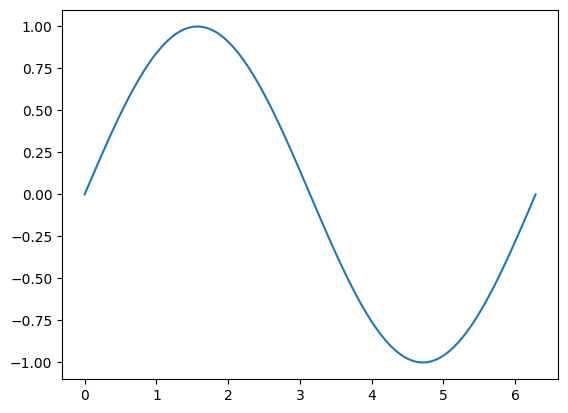

In [21]:
xs = np.linspace(0, 2*np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

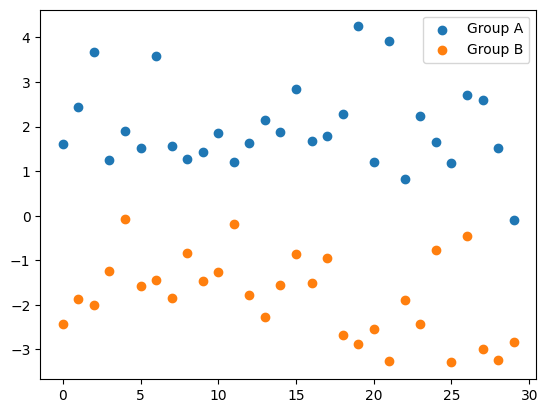

In [26]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
plt.scatter(x, group_a, color="C0", label="Group A")
plt.scatter(x, group_b, color="C1", label="Group B")

plt.legend()
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [27]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

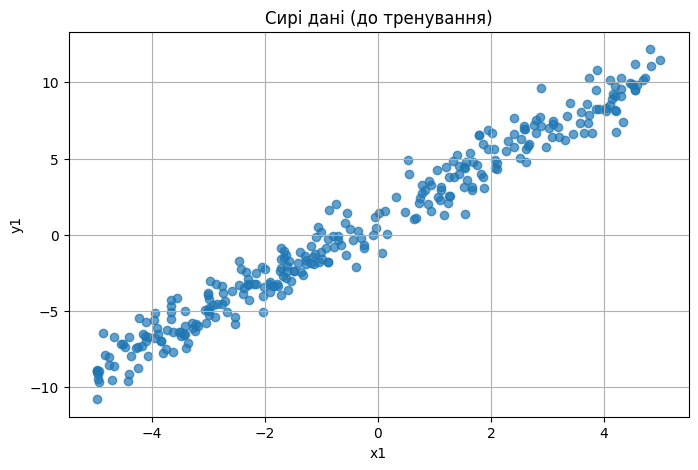

In [28]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"

plt.figure(figsize=(8, 5))
plt.scatter(x1.numpy(), y1.numpy(), alpha=0.7, color="C0")

plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.grid(True)
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [30]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
perm = torch.randperm(TASK1_N)

train_size = int(0.70 * TASK1_N)
val_size = int(0.15 * TASK1_N)

x_train1, y_train1 = x1[perm[:train_size]], y1[perm[:train_size]]
x_val1, y_val1 = (
    x1[perm[train_size : train_size + val_size]],
    y1[perm[train_size : train_size + val_size]],
)
x_test1, y_test1 = (
    x1[perm[train_size + val_size :]],
    y1[perm[train_size + val_size :]],
)

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [31]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=57.413548  w=1.4937 (true 2.0)  b=0.4546 (true 1.0)
epoch   30  loss=0.921201  w=1.9835 (true 2.0)  b=0.9634 (true 1.0)
epoch   60  loss=0.920473  w=1.9845 (true 2.0)  b=0.9868 (true 1.0)
epoch   90  loss=0.920471  w=1.9845 (true 2.0)  b=0.9878 (true 1.0)
epoch   99  loss=0.920471  w=1.9845 (true 2.0)  b=0.9879 (true 1.0)


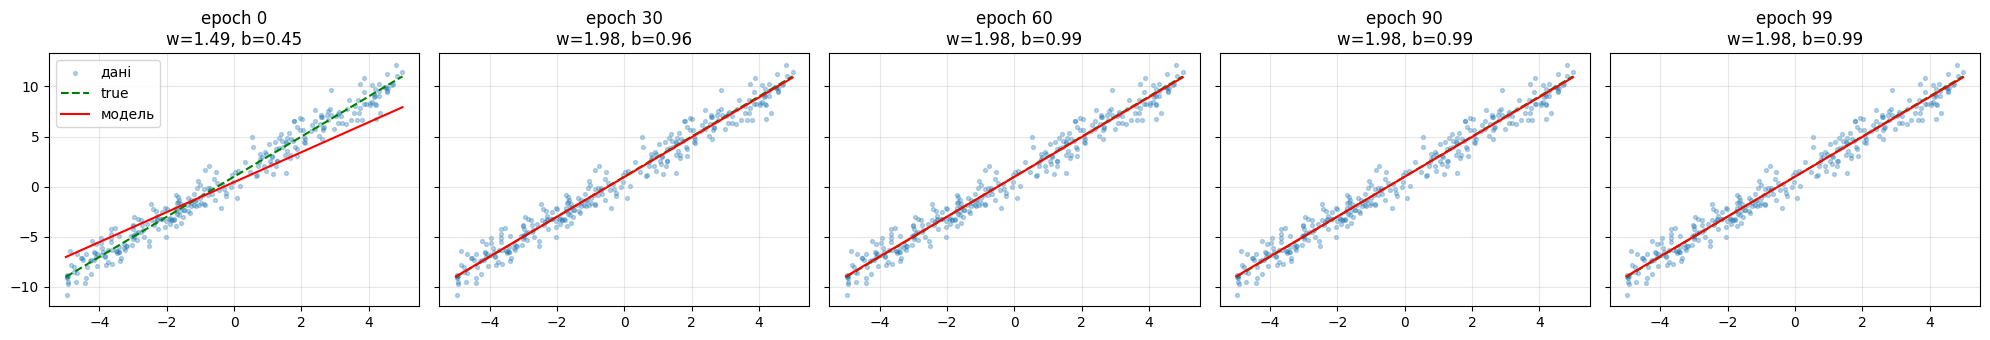

In [32]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

### Опис сценарію:
- **Тема:** Залежність середнього пульсу людини в спокої (удари за хвилину, bpm) від кількості випитих чашок кави за день.
- **Вхідна фіча (x):** Кількість чашок кави на день (діапазон від 0 до 6 чашок).
- **Цільова змінна (y):** Середній частота серцевих скорочень / пульс (bpm).

### Заперечена формула та обґрунтування параметрів:
  y = w * x + b + ε

- **b = 70.0 (Базовий рівень, Bias):** Базовий пульс здорової дорослої людини в стані спокою без вживання кофеїну становить приблизно 70 bpm.
- **w = 4.5 (Вага / Коефіцієнт, Weight):** Кожна додаткова випита чашка кави містить близько 80–100 мг кофеїну, що викликає помірне прискорення серцебиття в середньому на 4.5 bpm.
- **ε ~ N(0, 3.5^2) (Шум, Noise):** Враховує природну варіабельність між людьми (індивідуальна чутливість до кофеїну, рівень стресу, вік, рівень фізичної підготовки).

In [60]:
import torch.nn as nn
import torch.optim as optim

# Фіксуємо генератор випадкових чисел для відтворюваності результатів
torch.manual_seed(42)
np.random.seed(42)

TRUE_W = 4.5
TRUE_B = 70.0
N_SAMPLES = 500

snapshots = []
x_line = torch.linspace(0, 6, 100).unsqueeze(1)


def generate_data(n_samples=500, true_w=4.5, true_b=70.0, noise_std=3.5):
    x = torch.empty(n_samples, 1).uniform_(0.0, 6.0)
    noise = noise_std * torch.randn(n_samples, 1)
    y = true_w * x + true_b + noise
    return x, y


def save_dataset_to_csv(x, y, filepath="dataset.csv"):
    df = pd.DataFrame(
        {
            "coffee_cups_per_day": x.numpy().flatten(),
            "heart_rate_bpm": y.numpy().flatten(),
        }
    )

    dir_name = os.path.dirname(filepath)
    if dir_name:
        os.makedirs(dir_name, exist_ok=True)

    df.to_csv(filepath, index=False)
    print(f"[УСПІХ] Датасет успішно збережено у файл: {filepath}")
    return df


def split_data(x, y, train_ratio=0.70, val_ratio=0.15):
    n = len(x)
    perm = torch.randperm(n)
    train_size = int(train_ratio * n)
    val_size = int(val_ratio * n)

    x_train, y_train = x[perm[:train_size]], y[perm[:train_size]]
    x_val, y_val = (
        x[perm[train_size : train_size + val_size]],
        y[perm[train_size : train_size + val_size]],
    )
    x_test, y_test = (
        x[perm[train_size + val_size :]],
        y[perm[train_size + val_size :]],
    )

    return (x_train, y_train), (x_val, y_val), (x_test, y_test)


# 1. Генерація та збереження даних
x_custom, y_custom = generate_data(N_SAMPLES, TRUE_W, TRUE_B)
df_custom = save_dataset_to_csv(x_custom, y_custom, filepath="dataset.csv")

# 2. Розбиття на вибірки
(x_tr, y_tr), (x_v, y_v), (x_te, y_te) = split_data(x_custom, y_custom)
print(
    f"Розміри вибірок (train / val / test): {len(x_tr)} / {len(x_v)} /"
    f" {len(x_te)}"
)

# 3. Стандартизація вхідних даних
x_mean, x_std = x_tr.mean(), x_tr.std()
x_tr_norm = (x_tr - x_mean) / x_std
x_v_norm = (x_v - x_mean) / x_std
x_te_norm = (x_te - x_mean) / x_std
x_line_norm = (x_line - x_mean) / x_std


# 4. Навчання
def train_model(
    x_train_norm,
    y_train,
    x_val_norm,
    y_val,
    x_mean,
    x_std,
    lr=0.1,
    epochs=100,
):
    model = nn.Linear(in_features=1, out_features=1)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    print("\n--- Початок тренування моделі (100 епох зі стандартизацією) ---")
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        y_pred = model(x_train_norm)
        loss = loss_fn(y_pred, y_train)

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                val_pred = model(x_val_norm)
                val_loss = loss_fn(val_pred, y_val).item()
                y_line_pred = model(x_line_norm)

                w_raw = model.weight.item() / x_std.item()
                b_raw = model.bias.item() - (
                    model.weight.item() * x_mean.item() / x_std.item()
                )

                snapshots.append((epoch + 1, w_raw, b_raw, y_line_pred))

            print(
                f"Epoch [{epoch + 1:3d}/{epochs}] | "
                f"Train MSE Loss: {loss.item():.4f} | "
                f"Val MSE Loss: {val_loss:.4f} | "
                f"w: {w_raw:.4f} (true {TRUE_W}) | "
                f"b: {b_raw:.4f} (true {TRUE_B})"
            )

    return model


def evaluate_model(model, x_test_norm, y_test):
    model.eval()
    loss_fn = nn.MSELoss()
    with torch.no_grad():
        test_pred = model(x_test_norm)
        test_mse = loss_fn(test_pred, y_test).item()
        test_mae = torch.mean(torch.abs(test_pred - y_test)).item()

    print("\n--- Результати тестування моделі на тестовій вибірці ---")
    print(f"Test MSE Loss: {test_mse:.4f}")
    print(f"Test MAE Loss: {test_mae:.4f} bpm")
    return test_mse, test_mae


trained_model = train_model(
    x_tr_norm, y_tr, x_v_norm, y_v, x_mean, x_std, lr=0.1, epochs=100
)
evaluate_model(trained_model, x_te_norm, y_te)

[УСПІХ] Датасет успішно збережено у файл: dataset.csv
Розміри вибірок (train / val / test): 350 / 75 / 75

--- Початок тренування моделі (100 епох зі стандартизацією) ---
Epoch [ 20/100] | Train MSE Loss: 13.4974 | Val MSE Loss: 12.3534 | w: 4.4582 (true 4.5) | b: 69.1874 (true 70.0)
Epoch [ 40/100] | Train MSE Loss: 12.0813 | Val MSE Loss: 11.7989 | w: 4.5061 (true 4.5) | b: 69.9873 (true 70.0)
Epoch [ 60/100] | Train MSE Loss: 12.0811 | Val MSE Loss: 11.8029 | w: 4.5067 (true 4.5) | b: 69.9965 (true 70.0)
Epoch [ 80/100] | Train MSE Loss: 12.0811 | Val MSE Loss: 11.8030 | w: 4.5067 (true 4.5) | b: 69.9966 (true 70.0)
Epoch [100/100] | Train MSE Loss: 12.0811 | Val MSE Loss: 11.8030 | w: 4.5067 (true 4.5) | b: 69.9966 (true 70.0)

--- Результати тестування моделі на тестовій вибірці ---
Test MSE Loss: 8.7068
Test MAE Loss: 2.4383 bpm


(8.706839561462402, 2.4383418560028076)

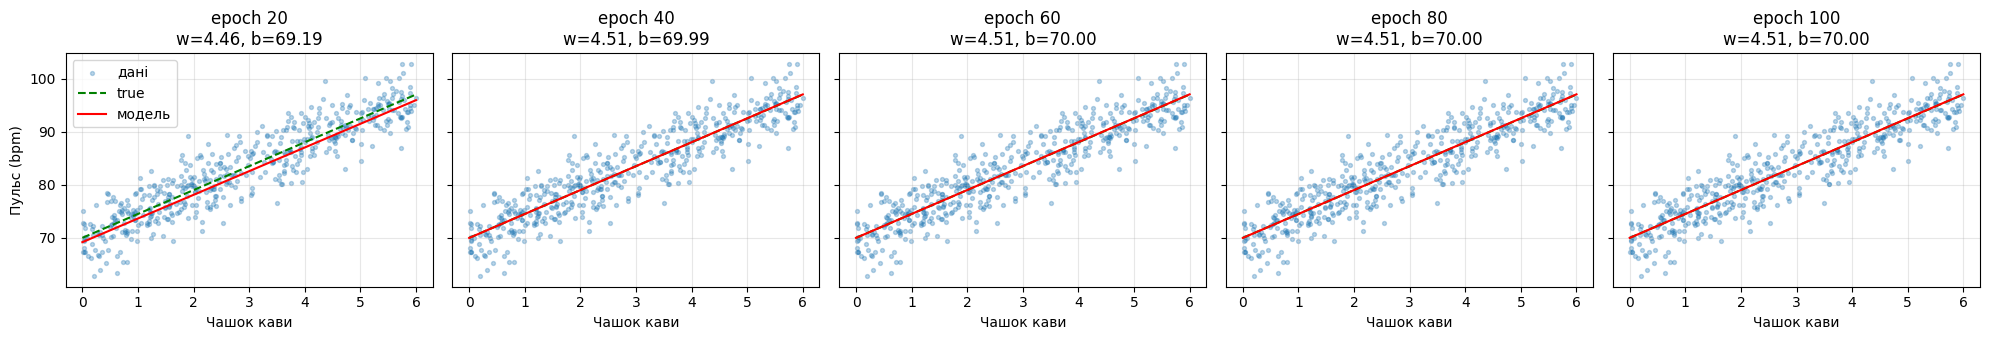

In [61]:
with torch.no_grad():
    y_line_true = TRUE_W * x_line + TRUE_B

fig, axes = plt.subplots(
    1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True
)

for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(
        x_custom.numpy(), y_custom.numpy(), s=8, alpha=0.3, label="дані"
    )
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.set_xlabel("Чашок кави")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Пульс (bpm)")
axes[0].legend()
plt.tight_layout()
plt.show()

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [62]:
MODEL_PATH = "model.pt"

torch.save(trained_model.state_dict(), MODEL_PATH)
print(f"\n[УСПІХ] Натреновану модель успішно збережено у файл: {MODEL_PATH}")


[УСПІХ] Натреновану модель успішно збережено у файл: model.pt


In [65]:
import shutil

# Копіюємо файли з /content/ у ваш ARTIFACT_DIR на Google Диску
shutil.copy("dataset.csv", os.path.join(ARTIFACT_DIR, "dataset.csv"))
shutil.copy("model.pt", os.path.join(ARTIFACT_DIR, "model.pt"))

print("Файли успішно скопійовано на Google Диск:")
print(os.path.join(ARTIFACT_DIR, "dataset.csv"))
print(os.path.join(ARTIFACT_DIR, "model.pt"))

Файли успішно скопійовано на Google Диск:
/content/drive/MyDrive/ai_systems/lab1/dataset.csv
/content/drive/MyDrive/ai_systems/lab1/model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [64]:
!pip install -q gradio
import gradio as gr

MODEL_PATH = os.path.join(ARTIFACT_DIR, "model.pt")

model = nn.Linear(in_features=1, out_features=1)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()


def load_and_predict(coffee_cups):
    """Здійснює передбачення пульсу з урахуванням стандартизації входу."""

    cups_float = float(coffee_cups)
    cups_normalized = (cups_float - x_mean.item()) / x_std.item()

    input_tensor = torch.tensor(
        [[cups_normalized]], dtype=torch.float32
    )

    with torch.no_grad():
        predicted_bpm = model(input_tensor).item()

    return f"Очікуваний середній пульс: {predicted_bpm:.1f} bpm"


# Створення Gradio інтерфейсу
demo = gr.Interface(
    fn=load_and_predict,
    inputs=gr.Slider(
        minimum=0.0,
        maximum=8.0,
        step=0.5,
        value=2.0,
        label="Кількість чашок кави на день",
    ),
    outputs=gr.Textbox(label="Прогноз моделі (bpm)"),
    title=(
        "☕ Прогноз впливу кави на частоту серцевих скорочень (Pulse Predictor)"
    ),
    description=(
        "Інтерактивний додаток для оцінки пульсу в спокої на основі"
        " натренованої лінійної регресії (PyTorch)."
    ),
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fda1c2e04125c8ea22.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```